# PIG Dataset — Piano Fingering Prediction

Bu notebook veri denetimi, piece-level split, Transformer baseline, kontrollü hiperparametre deneyleri, final test ve 3. hafta performans/müzikal analiz pipeline'ını tek dosyada yürütür.

In [1]:
import os
import glob
import math
import random
from pathlib import Path
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import music21

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

COLUMNS = [
    "note_id", "onset_time", "offset_time", "spelled_pitch",
    "onset_velocity", "offset_velocity", "channel", "finger_number"
]

In [2]:
SEED = 59
DATA_DIR = Path("FingeringFiles")
LIST_PATH = Path("List.csv")

SEQUENCE_LENGTH = 64
STRIDE = 64

BATCH_SIZE = 32
LEARNING_RATE = 1e-3
NUM_EPOCHS = 20
PATIENCE = 5
GRAD_CLIP = 1.0

HIDDEN_DIM = 128
NHEAD = 4
NUM_LAYERS = 3
DROPOUT = 0.1

FINGER_LOSS_WEIGHT = 1.0
HAND_LOSS_WEIGHT = 1.0

EXPECTED_PIECES = 150
EXPECTED_FINGERING_FILES = 309

CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

In [3]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Device: {DEVICE}")
print(f"Seed: {SEED}")
print(f"PyTorch: {torch.__version__}")
print(f"music21: {music21.__version__}")

Device: cpu
Seed: 59
PyTorch: 2.14.0+cpu
music21: 10.5.0


## 1. Dataset discovery

In [4]:
assert DATA_DIR.exists(), f"Dataset klasörü bulunamadı: {DATA_DIR}"
assert LIST_PATH.exists(), f"List.csv bulunamadı: {LIST_PATH}"

all_files = sorted(DATA_DIR.glob("*_fingering.txt"))
df_list = pd.read_csv(LIST_PATH)

print(f"Fingering dosyası: {len(all_files)}")
print(f"List.csv eser sayısı: {len(df_list)}")

assert len(all_files) == EXPECTED_FINGERING_FILES
assert len(df_list) == EXPECTED_PIECES

Fingering dosyası: 309
List.csv eser sayısı: 150


## 2. EDA

In [5]:
sample_file = all_files[0]
df_sample = pd.read_csv(
    sample_file, sep=r"\s+", comment="/", header=None, names=COLUMNS
)

display(df_sample.head())
print(f"Örnek dosya: {sample_file.name}")

,note_id,onset_time,offset_time,spelled_pitch,onset_velocity,offset_velocity,channel,finger_number
0,0,0.156289,0.302811,C4,64,80,0,1
1,1,0.312579,0.459100,D4,64,80,0,2
2,2,0.468869,0.615390,E4,64,80,0,3
3,3,0.625158,0.771679,F4,64,80,0,4
4,4,0.781447,0.927969,D4,64,80,0,2


Örnek dosya: 001-1_fingering.txt


Composer
Chopin          23
Bach            22
Beethoven       21
Mozart          20
Grieg           10
Debussy          9
Schumann         6
Schubert         5
Rachmaninoff     4
Ravel            3
Mussorgsky       3
Liszt            3
Brahms           3
Joplin           3
Mendelssohn      3
Faure            2
Satie            2
Scriabin         2
Dvorak           1
Tchaikovsky      1
Scarlatti        1
Saint-Saens      1
Bartok           1
Albeniz          1
Name: count, dtype: int64


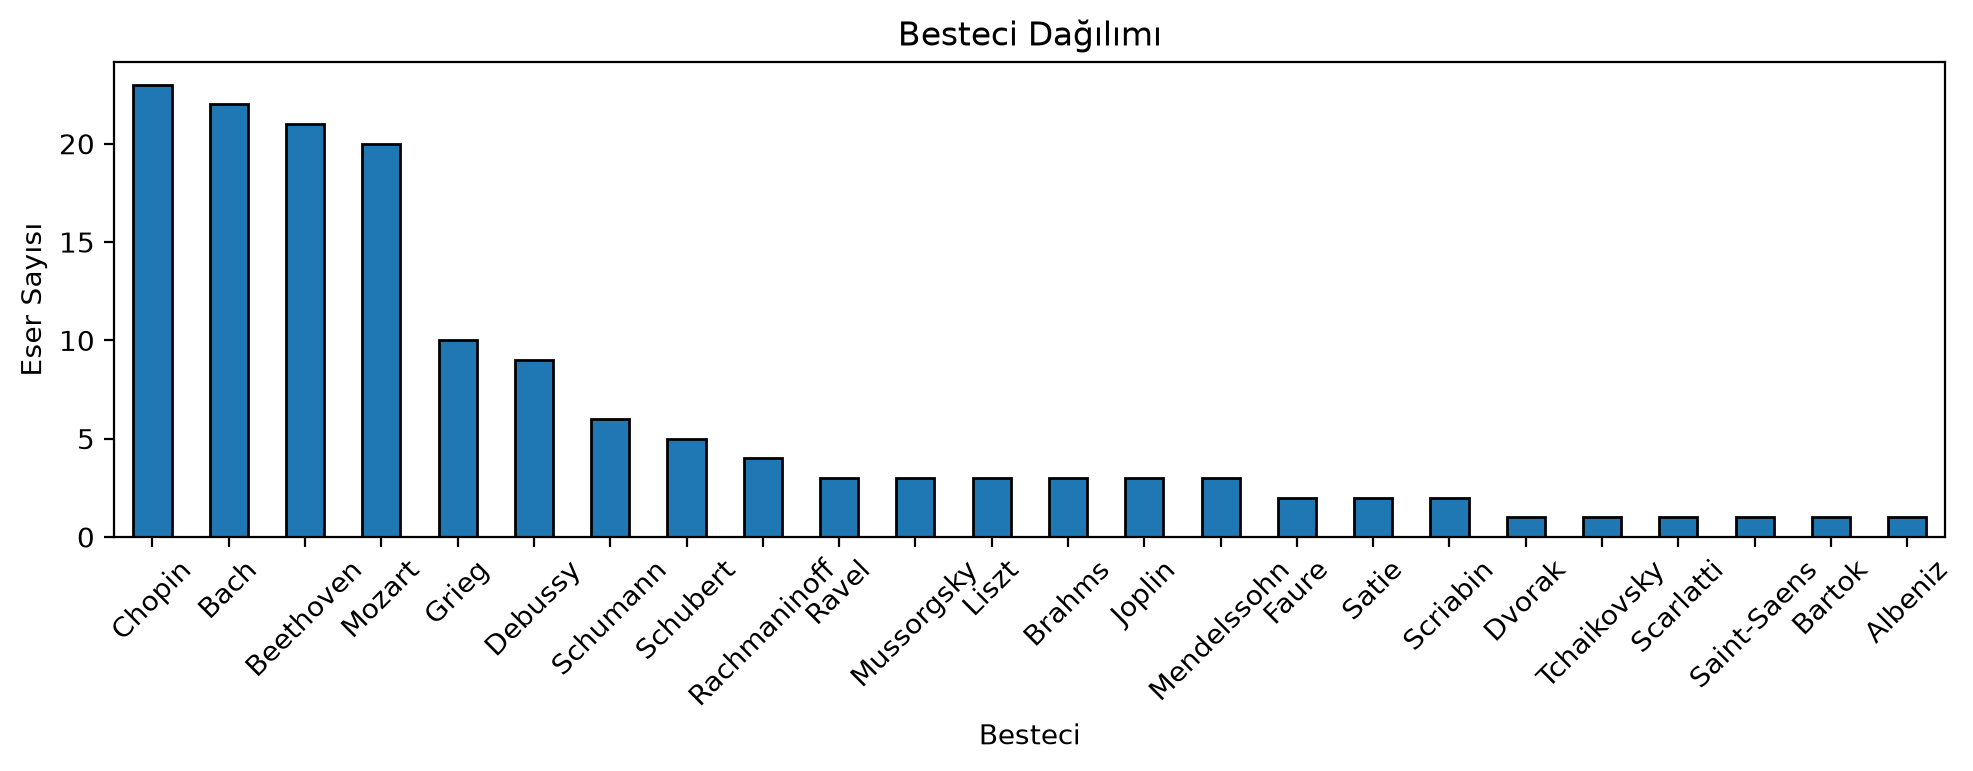

In [6]:
composer_counts = df_list["Composer"].value_counts()
print(composer_counts)

plt.figure(figsize=(10, 4))
composer_counts.plot(kind="bar", edgecolor="black")
plt.title("Besteci Dağılımı")
plt.xlabel("Besteci")
plt.ylabel("Eser Sayısı")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
df_sample["finger_clean"] = (
    df_sample["finger_number"].astype(str).str.split("_").str[0]
)
df_sample["finger_signed"] = pd.to_numeric(df_sample["finger_clean"], errors="coerce")

@lru_cache(maxsize=None)
def spelled_pitch_to_midi(value):
    return float(music21.pitch.Pitch(value).midi)

df_sample["midi_pitch"] = df_sample["spelled_pitch"].apply(spelled_pitch_to_midi)
display(df_sample[["note_id", "onset_time", "spelled_pitch", "midi_pitch", "channel", "finger_signed"]].head(10))

,note_id,onset_time,spelled_pitch,midi_pitch,channel,finger_signed
0,0,0.156289,C4,60.0,0,1
1,1,0.312579,D4,62.0,0,2
2,2,0.468869,E4,64.0,0,3
3,3,0.625158,F4,65.0,0,4
4,4,0.781447,D4,62.0,0,2
5,5,0.937737,E4,64.0,0,3
6,6,1.094030,C4,60.0,0,1
7,7,1.250320,G4,67.0,0,4
8,8,1.406610,C3,48.0,1,-5
9,9,1.562890,C5,72.0,0,4


In [8]:
records = []
for file_path in all_files:
    tmp = pd.read_csv(
        file_path, sep=r"\s+", comment="/", header=None, usecols=[6, 7],
        names=["channel", "finger_number"]
    )
    records.append(tmp)

all_fingers_df = pd.concat(records, ignore_index=True)
substitution_mask = all_fingers_df["finger_number"].astype(str).str.contains("_", regex=False)
substitution_count = int(substitution_mask.sum())
total_notes = len(all_fingers_df)
normal_count = total_notes - substitution_count

print(f"Toplam nota: {total_notes:,}")
print(f"Normal fingering: {normal_count:,}")
print(f"Substitution içeren: {substitution_count:,}")
print(f"Substitution oranı: {100 * substitution_count / total_notes:.2f}%")

Toplam nota: 100,040
Normal fingering: 99,716
Substitution içeren: 324
Substitution oranı: 0.32%


Sağ el
finger_signed
1    14396
2    12972
3    10757
4     7807
5     8307
Name: count, dtype: int64

Sol el
finger_signed
1    14654
2     9653
3     6585
4     4708
5    10201
Name: count, dtype: int64


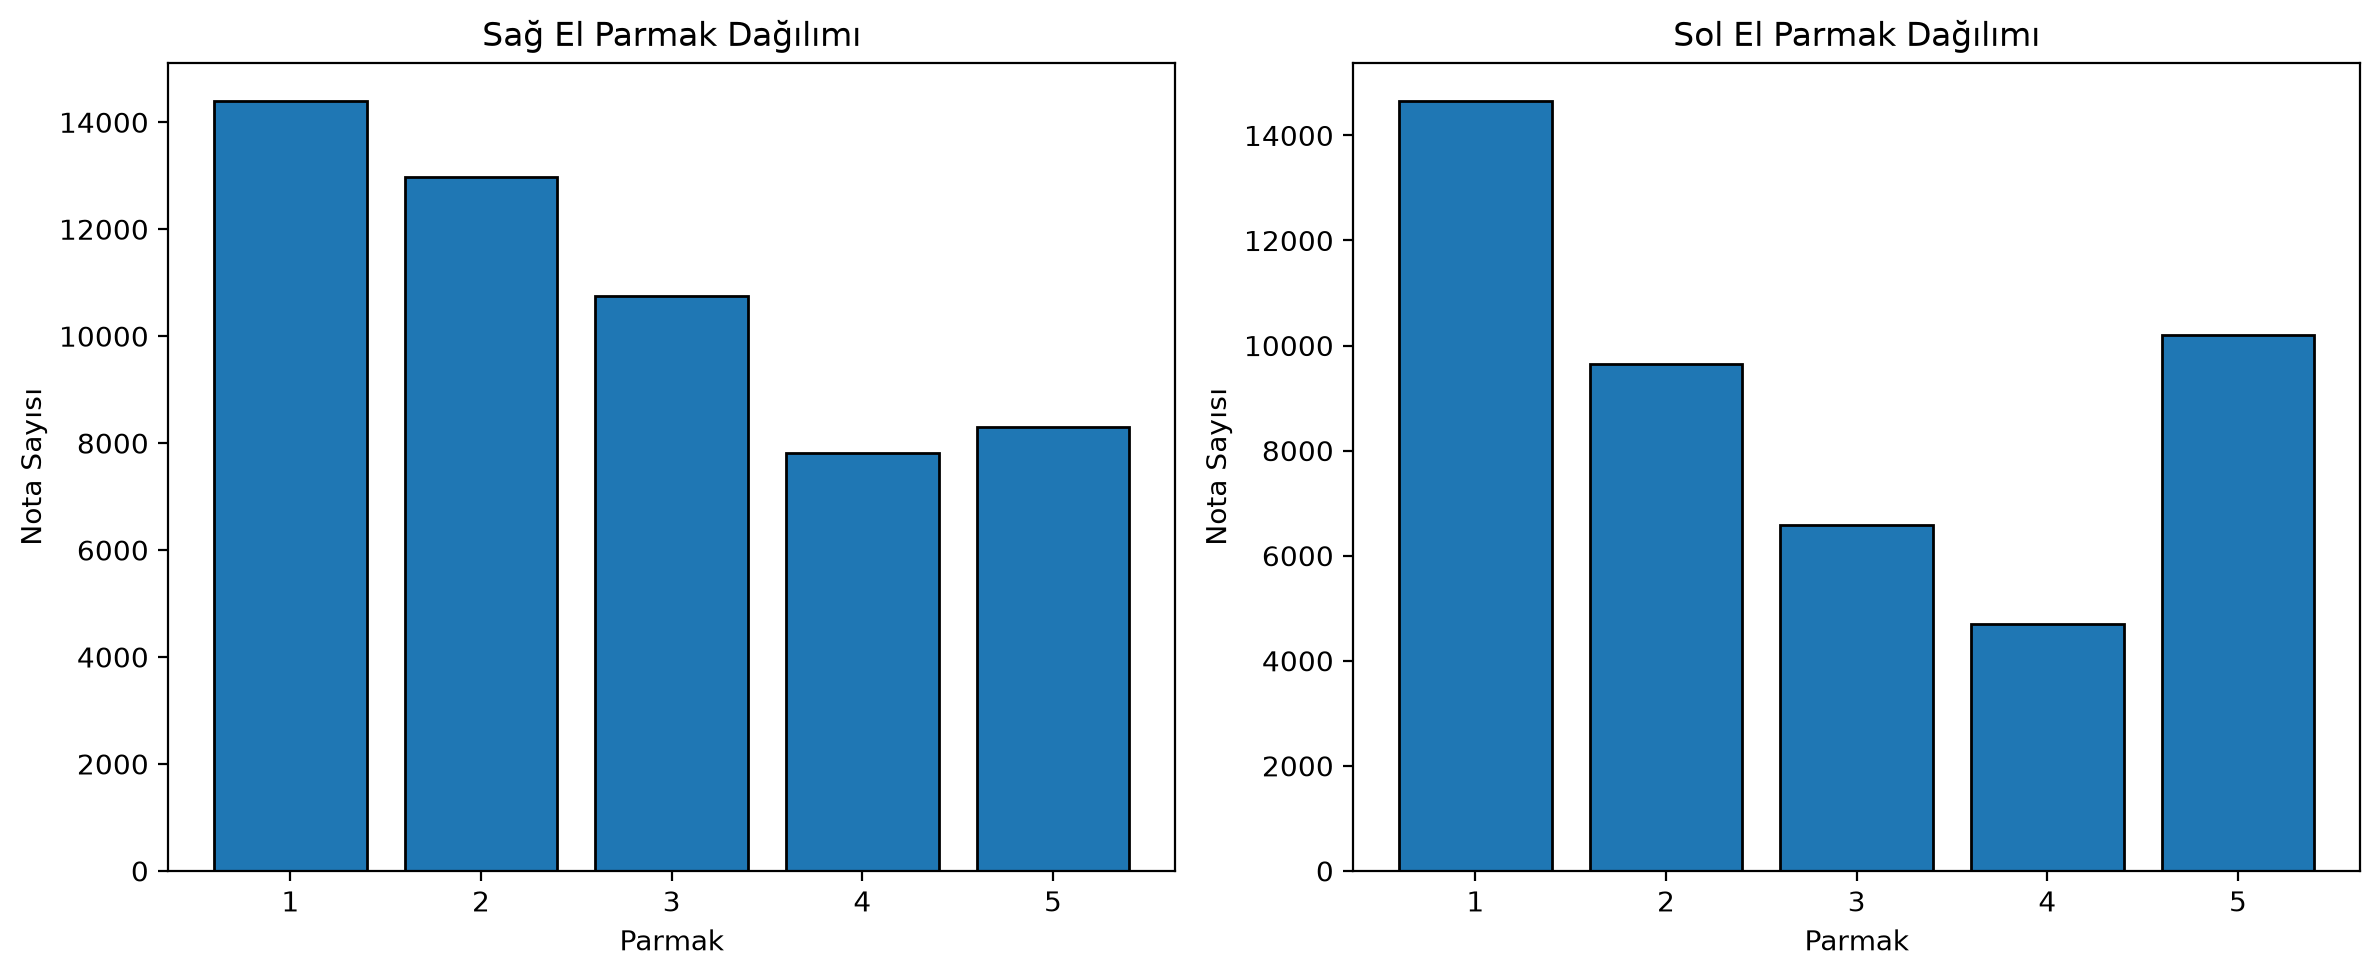

In [9]:
all_fingers_df["finger_clean"] = (
    all_fingers_df["finger_number"].astype(str).str.split("_").str[0]
)
all_fingers_df["finger_signed"] = pd.to_numeric(
    all_fingers_df["finger_clean"], errors="coerce"
)

right_hand_counts = (
    all_fingers_df.loc[all_fingers_df["channel"] == 0, "finger_signed"]
    .abs().value_counts().sort_index()
)
left_hand_counts = (
    all_fingers_df.loc[all_fingers_df["channel"] == 1, "finger_signed"]
    .abs().value_counts().sort_index()
)

print("Sağ el")
print(right_hand_counts)
print("\nSol el")
print(left_hand_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(right_hand_counts.index, right_hand_counts.values, edgecolor="black")
axes[0].set_title("Sağ El Parmak Dağılımı")
axes[0].set_xlabel("Parmak")
axes[0].set_ylabel("Nota Sayısı")
axes[0].set_xticks(range(1, 6))

axes[1].bar(left_hand_counts.index, left_hand_counts.values, edgecolor="black")
axes[1].set_title("Sol El Parmak Dağılımı")
axes[1].set_xlabel("Parmak")
axes[1].set_ylabel("Nota Sayısı")
axes[1].set_xticks(range(1, 6))

plt.tight_layout()
plt.show()

## 3. Data quality audit

In [10]:
def audit_file(file_path):
    df = pd.read_csv(
        file_path, sep=r"\s+", comment="/", header=None, names=COLUMNS
    )

    note_id = df["note_id"]
    onset = pd.to_numeric(df["onset_time"], errors="coerce")
    offset = pd.to_numeric(df["offset_time"], errors="coerce")
    channel = pd.to_numeric(df["channel"], errors="coerce")
    finger_clean = df["finger_number"].astype(str).str.split("_").str[0]
    finger_signed = pd.to_numeric(finger_clean, errors="coerce")

    invalid_pitch = 0
    for value in df["spelled_pitch"]:
        try:
            p = spelled_pitch_to_midi(value)
            if not np.isfinite(p):
                invalid_pitch += 1
        except Exception:
            invalid_pitch += 1

    valid_hf = channel.notna() & finger_signed.notna()
    mismatch = (
        valid_hf &
        ~(
            ((channel == 0) & (finger_signed > 0)) |
            ((channel == 1) & (finger_signed < 0))
        )
    )

    duration = offset - onset

    return {
        "file": file_path.name,
        "raw_rows": len(df),
        "missing_note_id": int(note_id.isna().sum()),
        "missing_onset": int(onset.isna().sum()),
        "missing_offset": int(offset.isna().sum()),
        "missing_pitch": int(df["spelled_pitch"].isna().sum()),
        "missing_channel": int(channel.isna().sum()),
        "missing_finger": int(finger_signed.isna().sum()),
        "invalid_channel": int((channel.notna() & ~channel.isin([0, 1])).sum()),
        "invalid_finger": int((finger_signed.notna() & ~finger_signed.abs().isin([1, 2, 3, 4, 5])).sum()),
        "negative_duration": int(((duration < 0) & duration.notna()).sum()),
        "invalid_onset": int((onset.notna() & ~np.isfinite(onset)).sum()),
        "invalid_offset": int((offset.notna() & ~np.isfinite(offset)).sum()),
        "invalid_pitch": int(invalid_pitch),
        "duplicate_note_id": int(note_id.duplicated().sum()),
        "hand_finger_mismatch": int(mismatch.sum()),
    }

audit_df = pd.DataFrame([audit_file(f) for f in all_files])
audit_error_columns = [c for c in audit_df.columns if c not in ["file", "raw_rows"]]
audit_summary = audit_df[audit_error_columns].sum().to_frame("count")

display(audit_summary)

assert (audit_summary["count"] == 0).all(), (
    "Data audit başarısız. Hatalar bulundu:\n" +
    str(audit_summary[audit_summary["count"] != 0])
)

print("✅ DATA QUALITY AUDIT PASSED")

,count
missing_note_id,0
missing_onset,0
missing_offset,0
missing_pitch,0
missing_channel,0
missing_finger,0
invalid_channel,0
invalid_finger,0
negative_duration,0
invalid_onset,0


✅ DATA QUALITY AUDIT PASSED


## 4. Piece-level split

In [11]:
piece_ids = sorted({f.name.split("-")[0] for f in all_files})
assert len(piece_ids) == EXPECTED_PIECES

set_seed(SEED)
shuffled_pieces = piece_ids.copy()
random.shuffle(shuffled_pieces)

train_idx = int(len(shuffled_pieces) * 0.70)
val_idx = int(len(shuffled_pieces) * 0.85)

train_pieces = set(shuffled_pieces[:train_idx])
val_pieces = set(shuffled_pieces[train_idx:val_idx])
test_pieces = set(shuffled_pieces[val_idx:])

train_files = [f for f in all_files if f.name.split("-")[0] in train_pieces]
val_files = [f for f in all_files if f.name.split("-")[0] in val_pieces]
test_files = [f for f in all_files if f.name.split("-")[0] in test_pieces]

split_table = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "pieces": [len(train_pieces), len(val_pieces), len(test_pieces)],
    "files": [len(train_files), len(val_files), len(test_files)],
})

display(split_table)

,split,pieces,files
0,train,105,208
1,validation,22,46
2,test,23,55


In [12]:
assert train_pieces.isdisjoint(val_pieces)
assert train_pieces.isdisjoint(test_pieces)
assert val_pieces.isdisjoint(test_pieces)
assert len(train_pieces | val_pieces | test_pieces) == len(piece_ids)
assert len(train_files) + len(val_files) + len(test_files) == len(all_files)

print("✅ SPLIT INTEGRITY CHECK PASSED")

✅ SPLIT INTEGRITY CHECK PASSED


## 5. Unified preprocessing and sequence dataset

In [13]:
def piece_id_from_file(file_path):
    return Path(file_path).name.split("-")[0]

def annotation_id_from_file(file_path):
    return Path(file_path).stem.replace("_fingering", "")


def load_and_clean_pig_file(file_path):
    df = pd.read_csv(
        file_path, sep=r"\s+", comment="/", header=None, names=COLUMNS
    )

    raw_rows = len(df)
    df["note_id_num"] = pd.to_numeric(df["note_id"], errors="coerce")
    df["onset_time"] = pd.to_numeric(df["onset_time"], errors="coerce")
    df["offset_time"] = pd.to_numeric(df["offset_time"], errors="coerce")
    df["channel"] = pd.to_numeric(df["channel"], errors="coerce")
    df["finger_clean"] = df["finger_number"].astype(str).str.split("_").str[0]
    df["finger_signed"] = pd.to_numeric(df["finger_clean"], errors="coerce")

    df = df.dropna(
        subset=["note_id", "onset_time", "offset_time", "spelled_pitch", "channel", "finger_signed"]
    ).copy()

    assert df["channel"].isin([0, 1]).all()
    assert df["finger_signed"].abs().isin([1, 2, 3, 4, 5]).all()

    hand_ok = (
        ((df["channel"] == 0) & (df["finger_signed"] > 0)) |
        ((df["channel"] == 1) & (df["finger_signed"] < 0))
    )
    assert hand_ok.all()

    df["finger"] = df["finger_signed"].abs().astype(int)
    df["midi_pitch"] = df["spelled_pitch"].apply(spelled_pitch_to_midi)
    df["duration"] = df["offset_time"] - df["onset_time"]

    assert (df["duration"] >= 0).all()
    assert np.isfinite(df["onset_time"]).all()
    assert np.isfinite(df["offset_time"]).all()
    assert np.isfinite(df["duration"]).all()
    assert np.isfinite(df["midi_pitch"]).all()

    if df["note_id_num"].notna().all():
        df = df.sort_values(["onset_time", "note_id_num"], kind="mergesort")
    else:
        df = df.sort_values(["onset_time", "note_id"], kind="mergesort")
    df = df.reset_index(drop=True)

    df["onset_diff"] = df["onset_time"].diff().fillna(0.0)
    assert np.isfinite(df["onset_diff"]).all()

    return df, raw_rows, len(df)


class PianoSequenceDataset(Dataset):
    def __init__(self, file_list, sequence_length, stride, feature_stats=None):
        self.sequence_length = sequence_length
        self.stride = stride
        self.inputs = []
        self.target_hands = []
        self.target_fingers = []
        self.metadata = []

        self.raw_rows = 0
        self.cleaned_rows = 0
        self.used_rows = 0
        self.discarded_rows = 0

        for file_path in file_list:
            df, raw_rows, cleaned_rows = load_and_clean_pig_file(file_path)
            self.raw_rows += raw_rows
            self.cleaned_rows += cleaned_rows

            X = df[["midi_pitch", "duration", "onset_diff"]].to_numpy(dtype=np.float32)
            if feature_stats is not None:
                X = (X - feature_stats["mean"]) / feature_stats["std"]

            y_hand = df["channel"].to_numpy(dtype=np.int64)
            y_finger = df["finger"].to_numpy(dtype=np.int64) - 1

            n_sequences = max(
                0,
                (len(df) - sequence_length) // stride + 1
            )

            used = n_sequences * sequence_length
            self.used_rows += used
            self.discarded_rows += len(df) - used

            annotation_id = annotation_id_from_file(file_path)
            piece_id = piece_id_from_file(file_path)

            for seq_idx, start in enumerate(range(
                0, len(df) - sequence_length + 1, stride
            )):
                end = start + sequence_length
                self.inputs.append(X[start:end])
                self.target_hands.append(y_hand[start:end])
                self.target_fingers.append(y_finger[start:end])
                self.metadata.append({
                    "file_id": annotation_id,
                    "piece_id": piece_id,
                    "sequence_index": seq_idx,
                    "start_row": start,
                    "note_id": df["note_id"].iloc[start:end].tolist(),
                    "onset_time": df["onset_time"].iloc[start:end].to_numpy(),
                    "offset_time": df["offset_time"].iloc[start:end].to_numpy(),
                    "midi_pitch": df["midi_pitch"].iloc[start:end].to_numpy(),
                    "duration": df["duration"].iloc[start:end].to_numpy(),
                    "onset_diff": df["onset_diff"].iloc[start:end].to_numpy(),
                    "true_hand": y_hand[start:end].copy(),
                    "true_finger": y_finger[start:end].copy(),
                })

        self.inputs = torch.tensor(np.asarray(self.inputs), dtype=torch.float32)
        self.target_hands = torch.tensor(np.asarray(self.target_hands), dtype=torch.long)
        self.target_fingers = torch.tensor(np.asarray(self.target_fingers), dtype=torch.long)

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs[idx], self.target_hands[idx], self.target_fingers[idx]

    def summary(self):
        return {
            "raw_rows": self.raw_rows,
            "cleaned_rows": self.cleaned_rows,
            "used_rows": self.used_rows,
            "discarded_rows": self.discarded_rows,
            "sequences": len(self),
        }

In [14]:
def get_train_stats(file_list):
    all_features = []
    for file_path in file_list:
        df, _, _ = load_and_clean_pig_file(file_path)
        all_features.append(
            df[["midi_pitch", "duration", "onset_diff"]].to_numpy(dtype=np.float64)
        )
    features = np.vstack(all_features)
    return {
        "mean": features.mean(axis=0),
        "std": features.std(axis=0) + 1e-8,
    }

train_stats = get_train_stats(train_files)
print("Train mean:", train_stats["mean"])
print("Train std :", train_stats["std"])

train_dataset = PianoSequenceDataset(
    train_files, SEQUENCE_LENGTH, STRIDE, train_stats
)
val_dataset = PianoSequenceDataset(
    val_files, SEQUENCE_LENGTH, STRIDE, train_stats
)
test_dataset = PianoSequenceDataset(
    test_files, SEQUENCE_LENGTH, STRIDE, train_stats
)

summary_df = pd.DataFrame([
    {"split": "train", **train_dataset.summary()},
    {"split": "validation", **val_dataset.summary()},
    {"split": "test", **test_dataset.summary()},
])

display(summary_df)

Train mean: [63.68299363  0.32805711  0.11541683]
Train std : [11.67267101  0.36669458  0.16171741]


,split,raw_rows,cleaned_rows,used_rows,discarded_rows,sequences
0,train,65352,65352,58816,6536,919
1,validation,15086,15086,13696,1390,214
2,test,19602,19602,18240,1362,285


## 6. DataLoader

In [15]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def make_loaders(train_ds, val_ds, batch_size, seed=SEED):
    generator = torch.Generator()
    generator.manual_seed(seed)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=0, worker_init_fn=seed_worker, generator=generator
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False, num_workers=0
    )
    return train_loader, val_loader

train_loader, val_loader = make_loaders(train_dataset, val_dataset, BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

x_batch, y_hand_batch, y_finger_batch = next(iter(train_loader))
print("Input:", x_batch.shape)
print("Hand target:", y_hand_batch.shape)
print("Finger target:", y_finger_batch.shape)
print("Batch feature mean:", x_batch.mean(dim=(0, 1)).numpy())
print("Batch feature std :", x_batch.std(dim=(0, 1)).numpy())

Input: torch.Size([32, 64, 3])
Hand target: torch.Size([32, 64])
Finger target: torch.Size([32, 64])
Batch feature mean: [-0.0601436  -0.08776027 -0.113077  ]
Batch feature std : [1.0769446  0.83844125 0.8657198 ]


## 7. Transformer baseline

In [16]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        position = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32)
            * (-math.log(10000.0) / d_model)
        )
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class PianoFingeringModel(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=HIDDEN_DIM, nhead=NHEAD, num_layers=NUM_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.pos_encoder = PositionalEncoding(hidden_dim, max_len=SEQUENCE_LENGTH)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=nhead,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers
        )
        self.hand_classifier = nn.Linear(hidden_dim, 2)
        self.finger_classifier = nn.Linear(hidden_dim, 5)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        features = self.transformer_encoder(x)
        return self.hand_classifier(features), self.finger_classifier(features)

In [17]:
set_seed()
smoke_model = PianoFingeringModel().to(DEVICE)
with torch.no_grad():
    smoke_hand, smoke_finger = smoke_model(x_batch.to(DEVICE))

print("Input:", x_batch.shape)
print("Hand output:", smoke_hand.shape)
print("Finger output:", smoke_finger.shape)
assert smoke_hand.shape == (BATCH_SIZE, SEQUENCE_LENGTH, 2)
assert smoke_finger.shape == (BATCH_SIZE, SEQUENCE_LENGTH, 5)
print("✅ Forward-pass smoke test geçti.")

Input: torch.Size([32, 64, 3])
Hand output: torch.Size([32, 64, 2])
Finger output: torch.Size([32, 64, 5])
✅ Forward-pass smoke test geçti.


## 8. Training

In [18]:
def run_training_experiment(config, train_ds, val_ds, seed=SEED, checkpoint_path=None):
    set_seed(seed)
    train_loader, val_loader = make_loaders(train_ds, val_ds, config["batch_size"], seed)

    model = PianoFingeringModel(
        input_dim=3,
        hidden_dim=config["hidden_dim"],
        nhead=config["nhead"],
        num_layers=config["num_layers"],
        dropout=config["dropout"],
    ).to(DEVICE)

    criterion_finger = nn.CrossEntropyLoss()
    criterion_hand = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=config["learning_rate"])

    history = {
        "train_loss": [], "val_loss": [],
        "train_finger_acc": [], "val_finger_acc": [],
        "train_hand_acc": [], "val_hand_acc": [],
    }

    best_val_acc = -1.0
    best_epoch = -1
    patience_counter = 0

    for epoch in range(config["epochs"]):
        model.train()
        train_loss_sum = 0.0
        train_finger_correct = train_finger_total = 0
        train_hand_correct = train_hand_total = 0

        for inputs, hands, fingers in train_loader:
            inputs = inputs.to(DEVICE)
            hands = hands.to(DEVICE)
            fingers = fingers.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            hand_logits, finger_logits = model(inputs)

            loss_hand = criterion_hand(hand_logits.reshape(-1, 2), hands.reshape(-1))
            loss_finger = criterion_finger(finger_logits.reshape(-1, 5), fingers.reshape(-1))
            loss = HAND_LOSS_WEIGHT * loss_hand + FINGER_LOSS_WEIGHT * loss_finger

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()

            train_loss_sum += loss.item()
            train_finger_pred = finger_logits.argmax(dim=-1)
            train_hand_pred = hand_logits.argmax(dim=-1)
            train_finger_correct += (train_finger_pred == fingers).sum().item()
            train_finger_total += fingers.numel()
            train_hand_correct += (train_hand_pred == hands).sum().item()
            train_hand_total += hands.numel()

        model.eval()
        val_loss_sum = 0.0
        val_finger_correct = val_finger_total = 0
        val_hand_correct = val_hand_total = 0

        with torch.no_grad():
            for inputs, hands, fingers in val_loader:
                inputs = inputs.to(DEVICE)
                hands = hands.to(DEVICE)
                fingers = fingers.to(DEVICE)

                hand_logits, finger_logits = model(inputs)
                loss_hand = criterion_hand(hand_logits.reshape(-1, 2), hands.reshape(-1))
                loss_finger = criterion_finger(finger_logits.reshape(-1, 5), fingers.reshape(-1))
                val_loss_sum += (
                    HAND_LOSS_WEIGHT * loss_hand + FINGER_LOSS_WEIGHT * loss_finger
                ).item()

                val_finger_pred = finger_logits.argmax(dim=-1)
                val_hand_pred = hand_logits.argmax(dim=-1)
                val_finger_correct += (val_finger_pred == fingers).sum().item()
                val_finger_total += fingers.numel()
                val_hand_correct += (val_hand_pred == hands).sum().item()
                val_hand_total += hands.numel()

        metrics = {
            "train_loss": train_loss_sum / len(train_loader),
            "val_loss": val_loss_sum / len(val_loader),
            "train_finger_acc": train_finger_correct / train_finger_total,
            "val_finger_acc": val_finger_correct / val_finger_total,
            "train_hand_acc": train_hand_correct / train_hand_total,
            "val_hand_acc": val_hand_correct / val_hand_total,
        }

        for key, value in metrics.items():
            history[key].append(value)

        print(
            f"Epoch {epoch+1:02d}/{config['epochs']} | "
            f"Train Loss {metrics['train_loss']:.4f} | "
            f"Val Loss {metrics['val_loss']:.4f} | "
            f"Train Finger {100*metrics['train_finger_acc']:.2f}% | "
            f"Val Finger {100*metrics['val_finger_acc']:.2f}% | "
            f"Val Hand {100*metrics['val_hand_acc']:.2f}%"
        )

        if metrics["val_finger_acc"] > best_val_acc:
            best_val_acc = metrics["val_finger_acc"]
            best_epoch = epoch + 1
            patience_counter = 0
            if checkpoint_path is not None:
                torch.save(
                    {
                        "model_state_dict": model.state_dict(),
                        "config": config,
                        "epoch": best_epoch,
                        "best_val_finger_acc": best_val_acc,
                    },
                    checkpoint_path,
                )
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                break

    return history, best_epoch, best_val_acc

## 9. Hyperparameter experiments

In [19]:
EXPERIMENTS = {
    "baseline": {
        "epochs": 20, "batch_size": 32, "learning_rate": 1e-3,
        "hidden_dim": 128, "nhead": 4, "num_layers": 3, "dropout": 0.1,
    },
    "lr_3e-4": {
        "epochs": 20, "batch_size": 32, "learning_rate": 3e-4,
        "hidden_dim": 128, "nhead": 4, "num_layers": 3, "dropout": 0.1,
    },
    "batch_64": {
        "epochs": 20, "batch_size": 64, "learning_rate": 1e-3,
        "hidden_dim": 128, "nhead": 4, "num_layers": 3, "dropout": 0.1,
    },
    "epochs_10": {
        "epochs": 10, "batch_size": 32, "learning_rate": 1e-3,
        "hidden_dim": 128, "nhead": 4, "num_layers": 3, "dropout": 0.1,
    },
}

experiment_results = []
experiment_histories = {}
checkpoint_paths = {}

for name, config in EXPERIMENTS.items():
    path = CHECKPOINT_DIR / f"{name}.pt"
    print(f"\n===== {name} =====")
    history, best_epoch, best_val_acc = run_training_experiment(
        config, train_dataset, val_dataset, SEED, path
    )
    experiment_histories[name] = history
    checkpoint_paths[name] = str(path)
    experiment_results.append({
        "experiment": name,
        "best_epoch": best_epoch,
        "best_val_finger_accuracy": best_val_acc,
        "checkpoint": str(path),
    })

experiment_results_df = pd.DataFrame(experiment_results).sort_values(
    "best_val_finger_accuracy", ascending=False
).reset_index(drop=True)

display(experiment_results_df)

BEST_EXPERIMENT = experiment_results_df.loc[0, "experiment"]
BEST_CHECKPOINT = checkpoint_paths[BEST_EXPERIMENT]
BEST_CONFIG = EXPERIMENTS[BEST_EXPERIMENT]

print(f"Seçilen final konfigürasyon: {BEST_EXPERIMENT}")


===== baseline =====
Epoch 01/20 | Train Loss 1.7133 | Val Loss 1.4914 | Train Finger 35.69% | Val Finger 39.79% | Val Hand 95.91%
Epoch 02/20 | Train Loss 1.4424 | Val Loss 1.3262 | Train Finger 44.75% | Val Finger 46.84% | Val Hand 96.93%
Epoch 03/20 | Train Loss 1.3197 | Val Loss 1.2441 | Train Finger 48.78% | Val Finger 51.81% | Val Hand 97.37%
Epoch 04/20 | Train Loss 1.2613 | Val Loss 1.1563 | Train Finger 51.05% | Val Finger 51.82% | Val Hand 97.58%
Epoch 05/20 | Train Loss 1.1793 | Val Loss 1.1306 | Train Finger 53.48% | Val Finger 51.75% | Val Hand 97.82%
Epoch 06/20 | Train Loss 1.1539 | Val Loss 1.1736 | Train Finger 54.62% | Val Finger 49.49% | Val Hand 97.54%
Epoch 07/20 | Train Loss 1.1083 | Val Loss 1.0950 | Train Finger 56.09% | Val Finger 52.58% | Val Hand 97.77%
Epoch 08/20 | Train Loss 1.0960 | Val Loss 1.0849 | Train Finger 56.43% | Val Finger 52.75% | Val Hand 97.79%
Epoch 09/20 | Train Loss 1.0652 | Val Loss 1.1380 | Train Finger 57.13% | Val Finger 54.17% | Val 

,experiment,best_epoch,best_val_finger_accuracy,checkpoint
0,batch_64,18,0.590610,checkpoints\batch_64.pt
1,baseline,14,0.573671,checkpoints\baseline.pt
2,epochs_10,10,0.555345,checkpoints\epochs_10.pt
3,lr_3e-4,20,0.553154,checkpoints\lr_3e-4.pt


Seçilen final konfigürasyon: batch_64


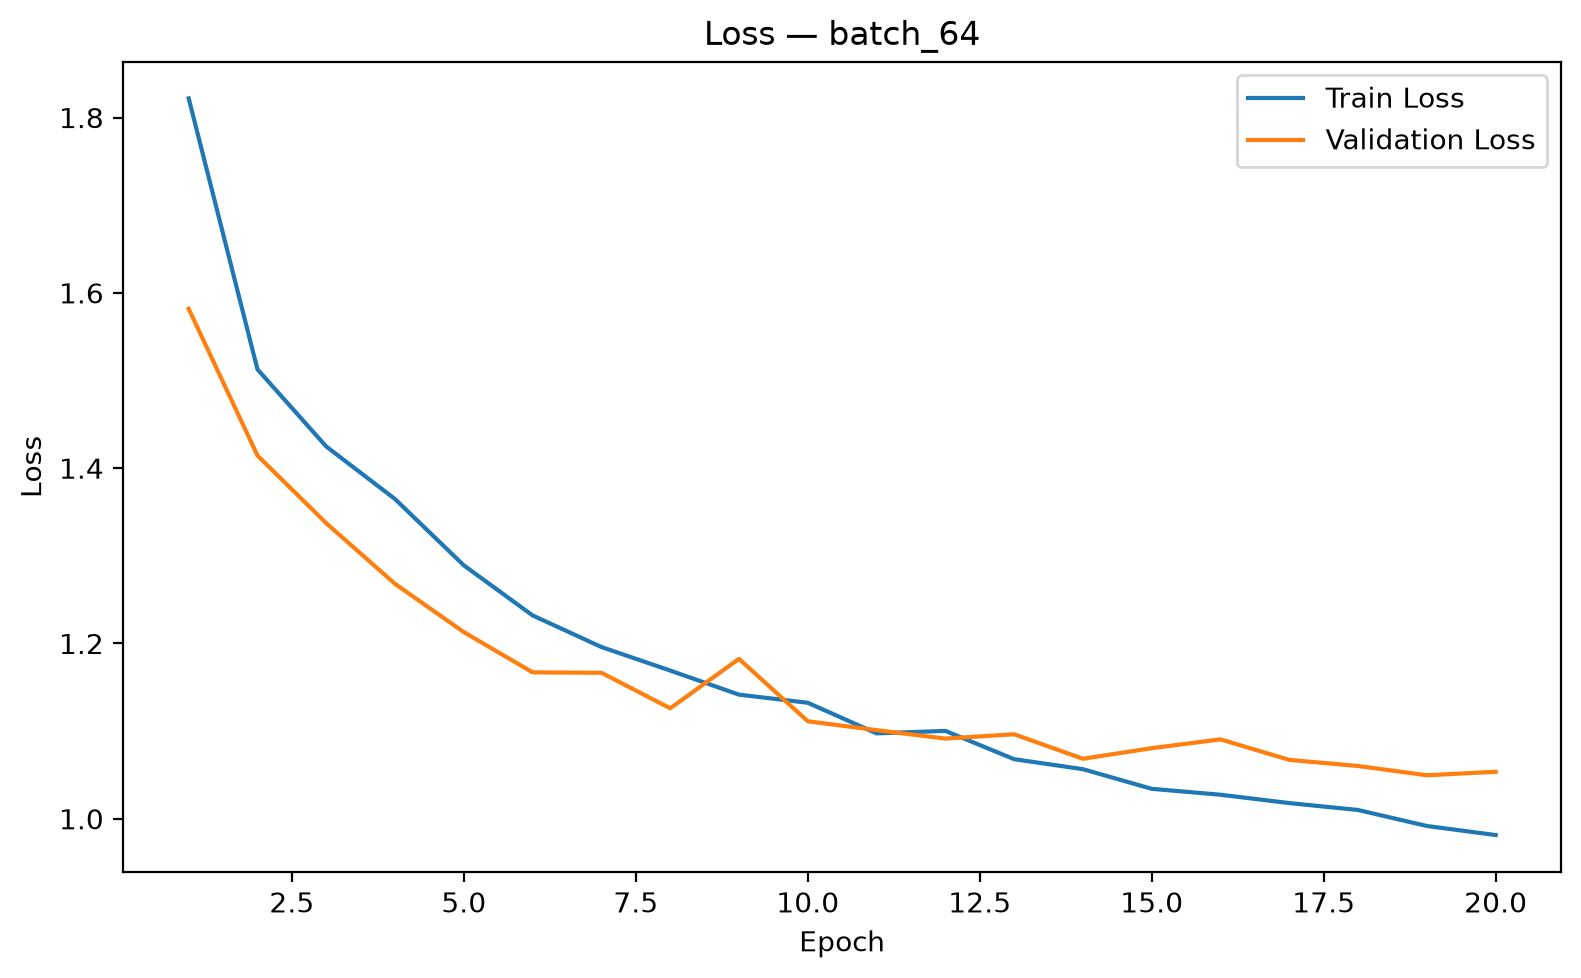

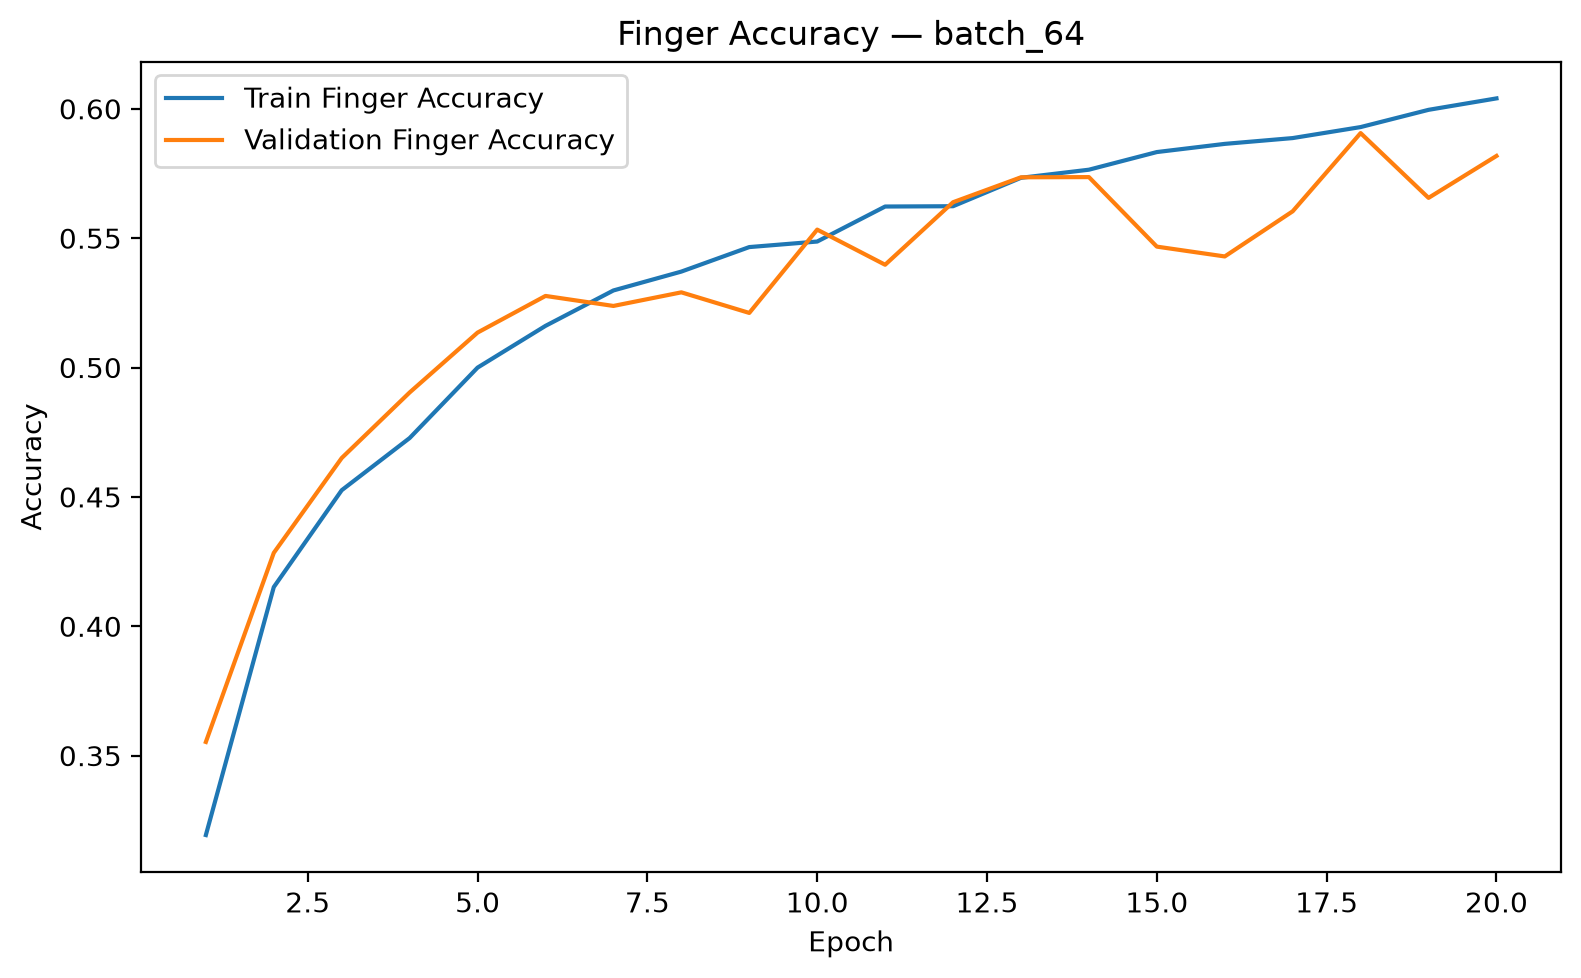

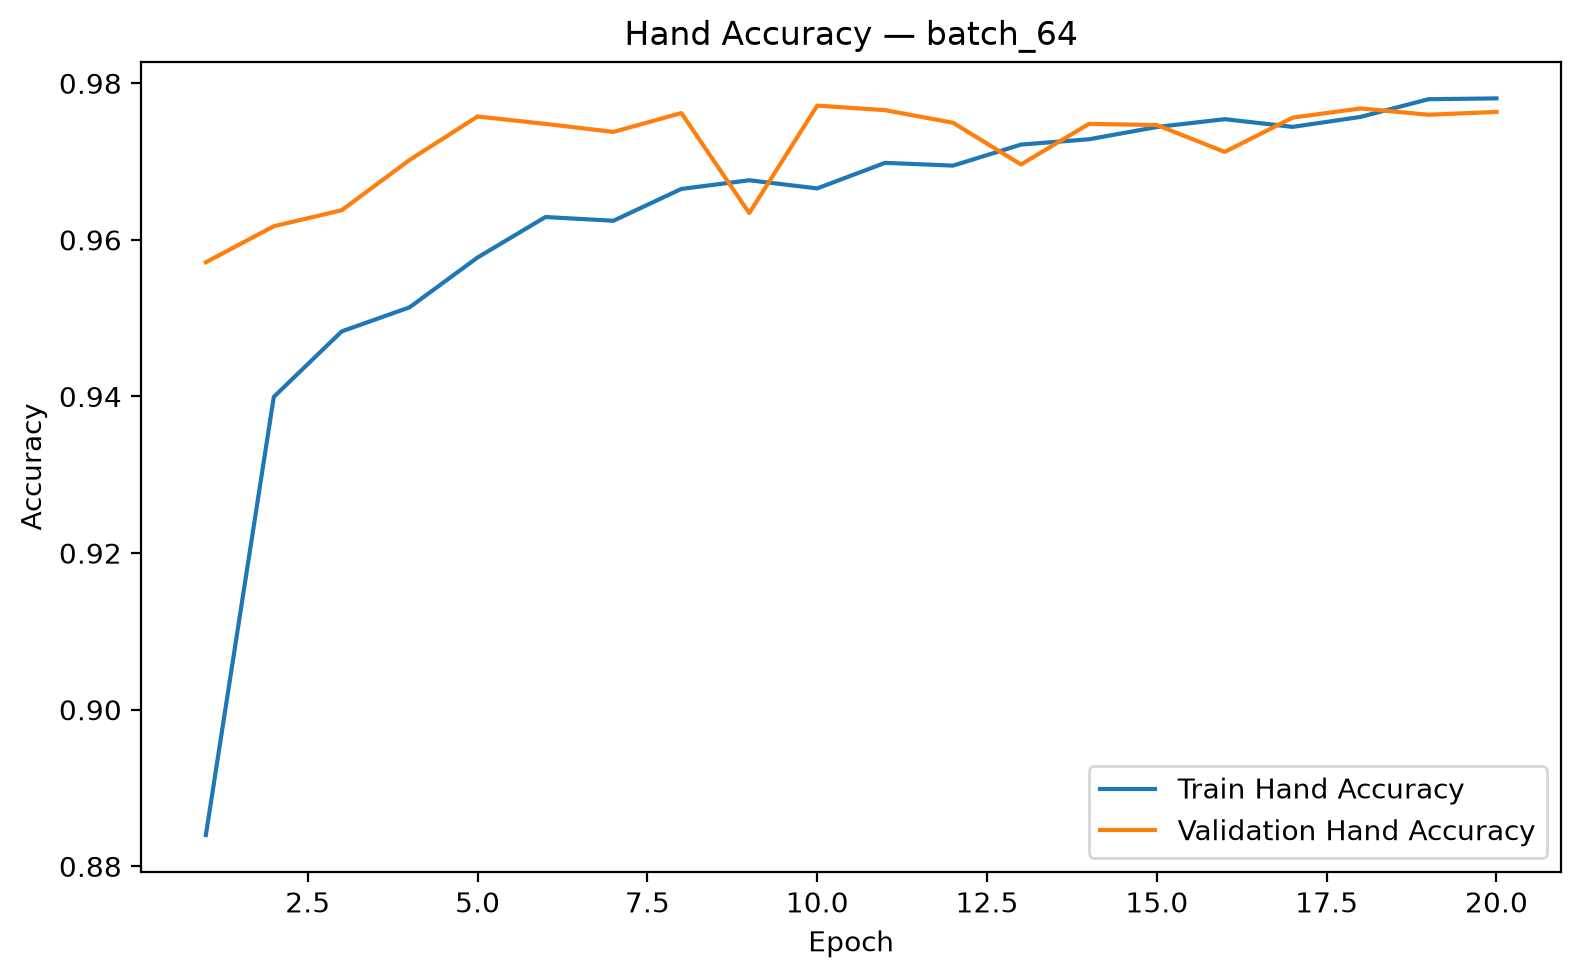

In [20]:
selected_history = experiment_histories[BEST_EXPERIMENT]

def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss — {BEST_EXPERIMENT}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_finger_acc"], label="Train Finger Accuracy")
    plt.plot(epochs, history["val_finger_acc"], label="Validation Finger Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Finger Accuracy — {BEST_EXPERIMENT}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_hand_acc"], label="Train Hand Accuracy")
    plt.plot(epochs, history["val_hand_acc"], label="Validation Hand Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Hand Accuracy — {BEST_EXPERIMENT}")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(selected_history)

## 10. Final test

In [21]:
def load_checkpoint_model(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    config = checkpoint["config"]
    model = PianoFingeringModel(
        input_dim=3,
        hidden_dim=config["hidden_dim"],
        nhead=config["nhead"],
        num_layers=config["num_layers"],
        dropout=config["dropout"],
    ).to(DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model, checkpoint

final_model, final_checkpoint = load_checkpoint_model(BEST_CHECKPOINT)
print("Final model yüklendi.")
print(f"Best epoch: {final_checkpoint['epoch']}")
print(f"Best validation finger accuracy: {100*final_checkpoint['best_val_finger_acc']:.2f}%")

Final model yüklendi.
Best epoch: 18
Best validation finger accuracy: 59.06%


In [22]:
def collect_predictions(model, dataset, batch_size=BATCH_SIZE):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    rows = []
    global_index = 0

    with torch.no_grad():
        for inputs, hands, fingers in loader:
            inputs = inputs.to(DEVICE)
            hand_logits, finger_logits = model(inputs)
            pred_hands = hand_logits.argmax(dim=-1).cpu().numpy()
            pred_fingers = finger_logits.argmax(dim=-1).cpu().numpy()

            batch_size_actual = inputs.size(0)
            for j in range(batch_size_actual):
                meta = dataset.metadata[global_index + j]
                for k in range(dataset.sequence_length):
                    rows.append({
                        "file_id": meta["file_id"],
                        "piece_id": meta["piece_id"],
                        "sequence_index": meta["sequence_index"],
                        "position_in_sequence": k,
                        "note_id": meta["note_id"][k],
                        "onset_time": float(meta["onset_time"][k]),
                        "offset_time": float(meta["offset_time"][k]),
                        "midi_pitch": float(meta["midi_pitch"][k]),
                        "duration": float(meta["duration"][k]),
                        "onset_diff": float(meta["onset_diff"][k]),
                        "true_hand": int(meta["true_hand"][k]),
                        "pred_hand": int(pred_hands[j, k]),
                        "true_finger": int(meta["true_finger"][k]) + 1,
                        "pred_finger": int(pred_fingers[j, k]) + 1,
                    })
            global_index += batch_size_actual

    result = pd.DataFrame(rows)
    result["finger_correct"] = result["true_finger"] == result["pred_finger"]
    result["hand_correct"] = result["true_hand"] == result["pred_hand"]
    return result

prediction_df = collect_predictions(final_model, test_dataset)
print(f"Test prediction rows: {len(prediction_df):,}")

Test prediction rows: 18,240


=== TEST METRICS ===
Finger accuracy: 0.6066
Hand accuracy  : 0.9684
Finger macro F1: 0.5412
Finger weighted F1: 0.5960

=== FINGER CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           1       0.74      0.77      0.76      5499
           2       0.50      0.53      0.52      4050
           3       0.40      0.32      0.35      2718
           4       0.36      0.27      0.31      2048
           5       0.72      0.82      0.77      3925

    accuracy                           0.61     18240
   macro avg       0.54      0.54      0.54     18240
weighted avg       0.59      0.61      0.60     18240



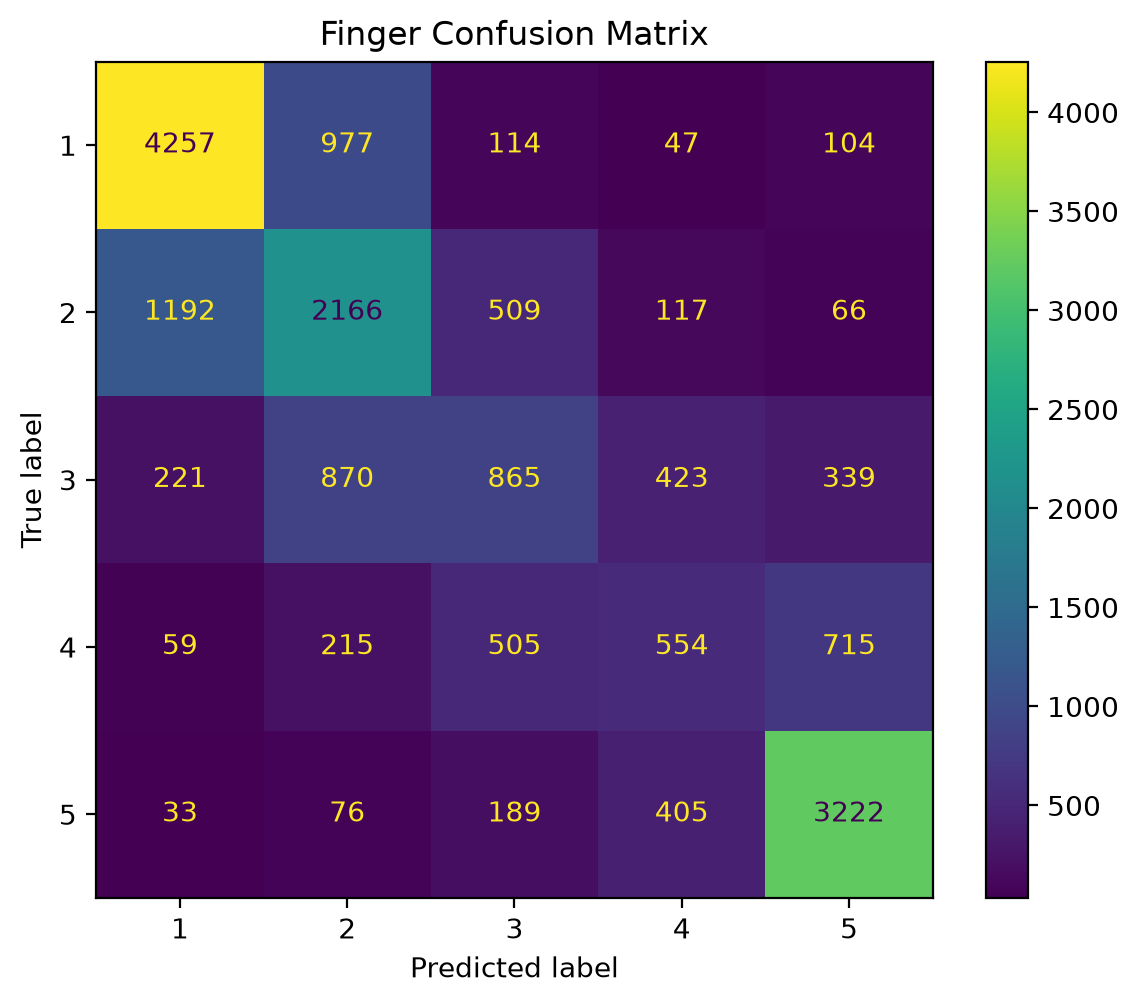

In [23]:
print("=== TEST METRICS ===")
print(f"Finger accuracy: {accuracy_score(prediction_df['true_finger'], prediction_df['pred_finger']):.4f}")
print(f"Hand accuracy  : {accuracy_score(prediction_df['true_hand'], prediction_df['pred_hand']):.4f}")
print(f"Finger macro F1: {f1_score(prediction_df['true_finger'], prediction_df['pred_finger'], average='macro'):.4f}")
print(f"Finger weighted F1: {f1_score(prediction_df['true_finger'], prediction_df['pred_finger'], average='weighted'):.4f}")

print("\n=== FINGER CLASSIFICATION REPORT ===")
print(classification_report(
    prediction_df["true_finger"], prediction_df["pred_finger"],
    labels=[1,2,3,4,5], zero_division=0
))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(
        prediction_df["true_finger"], prediction_df["pred_finger"], labels=[1,2,3,4,5]
    ),
    display_labels=[1,2,3,4,5]
).plot(ax=ax)
ax.set_title("Finger Confusion Matrix")
plt.tight_layout()
plt.show()

## 11. Per-finger and per-piece analysis

In [24]:
per_finger = (
    prediction_df.groupby("true_finger")
    .agg(
        notes=("finger_correct", "size"),
        accuracy=("finger_correct", "mean"),
    )
    .reset_index()
)
per_finger["accuracy_percent"] = 100 * per_finger["accuracy"]

piece_metrics = (
    prediction_df.groupby(["piece_id", "file_id"])
    .agg(
        notes=("finger_correct", "size"),
        finger_accuracy=("finger_correct", "mean"),
        hand_accuracy=("hand_correct", "mean"),
    )
    .reset_index()
)

print("Per-finger:")
display(per_finger)
print("Per-file / piece:")
display(piece_metrics.sort_values("finger_accuracy"))

Per-finger:


,true_finger,notes,accuracy,accuracy_percent
0,1,5499,0.774141,77.414075
1,2,4050,0.534815,53.481481
2,3,2718,0.318249,31.824871
3,4,2048,0.270508,27.050781
4,5,3925,0.820892,82.089172


Per-file / piece:


,piece_id,file_id,notes,finger_accuracy,hand_accuracy
6,006,006-5,320,0.431250,0.987500
7,006,006-8,320,0.434375,0.987500
4,006,006-1,320,0.446875,0.987500
0,003,003-1,384,0.468750,0.927083
49,125,125-2,192,0.468750,0.989583
2,003,003-5,384,0.473958,0.940104
3,003,003-8,384,0.473958,0.940104
5,006,006-2,320,0.487500,0.987500
35,041,041-1,320,0.490625,0.981250
50,138,138-1,256,0.500000,0.820312


## 12. Week 3 — temporal and musical difficulty analysis

In [25]:
pred = prediction_df.sort_values(
    ["file_id", "sequence_index", "position_in_sequence"]
).copy()

pred["pitch_interval"] = pred.groupby("file_id")["midi_pitch"].diff().abs().fillna(0.0)
pred["same_onset"] = pred["onset_diff"].eq(0)
pred["chord_size"] = pred.groupby(["file_id", "onset_time"])["note_id"].transform("count")

piece_rows = []
for file_path in test_files:
    df_piece, _, _ = load_and_clean_pig_file(file_path)
    if len(df_piece) < 2:
        continue
    span = max(float(df_piece["onset_time"].max() - df_piece["onset_time"].min()), 1e-8)
    piece_rows.append({
        "piece_id": piece_id_from_file(file_path),
        "file_id": annotation_id_from_file(file_path),
        "notes": len(df_piece),
        "duration_span": span,
        "notes_per_second": len(df_piece) / span,
    })
piece_temporal = pd.DataFrame(piece_rows)

pred = pred.merge(
    piece_temporal[["piece_id", "file_id", "notes_per_second"]],
    on=["piece_id", "file_id"],
    how="left"
)

print("Temporal density is used as a speed proxy; BPM is not inferred from onset times.")

Temporal density is used as a speed proxy; BPM is not inferred from onset times.


In [26]:
def binned_error_table(df, feature, q=4):
    temp = df[[feature, "finger_correct"]].dropna().copy()
    if temp[feature].nunique() < 2:
        return pd.DataFrame()
    temp["bin"] = pd.qcut(temp[feature], q=q, duplicates="drop")
    out = temp.groupby("bin", observed=False).agg(
        notes=("finger_correct", "size"),
        accuracy=("finger_correct", "mean"),
    ).reset_index()
    out["error_rate"] = 1.0 - out["accuracy"]
    return out

print("Pitch interval bins")
display(binned_error_table(pred, "pitch_interval"))

print("Chord size bins")
display(binned_error_table(pred, "chord_size"))

print("Temporal density bins")
display(binned_error_table(pred, "notes_per_second"))

Pitch interval bins


,bin,notes,accuracy,error_rate
0,"(-0.001, 4.0]",5359,0.522486,0.477514
1,"(4.0, 9.0]",4453,0.647204,0.352796
2,"(9.0, 16.0]",4264,0.624296,0.375704
3,"(16.0, 64.0]",4164,0.653218,0.346782


Chord size bins


,bin,notes,accuracy,error_rate
0,"(0.999, 2.0]",8321,0.525418,0.474582
1,"(2.0, 3.0]",3732,0.606109,0.393891
2,"(3.0, 4.0]",2116,0.662571,0.337429
3,"(4.0, 9.0]",4071,0.743798,0.256202


Temporal density bins


,bin,notes,accuracy,error_rate
0,"(4.005, 6.866]",4608,0.578125,0.421875
1,"(6.866, 9.879]",4672,0.544092,0.455908
2,"(9.879, 12.514]",5056,0.625989,0.374011
3,"(12.514, 21.249]",3904,0.689805,0.310195


## 13. Week 3 — hard passages

In [27]:
sequence_metrics = (
    pred.groupby(["piece_id", "file_id", "sequence_index"])
    .agg(
        notes=("finger_correct", "size"),
        finger_accuracy=("finger_correct", "mean"),
        mean_pitch_interval=("pitch_interval", "mean"),
        mean_chord_size=("chord_size", "mean"),
        notes_per_second=("notes_per_second", "first"),
        start_onset=("onset_time", "min"),
        end_onset=("onset_time", "max"),
    )
    .reset_index()
)
sequence_metrics["error_rate"] = 1.0 - sequence_metrics["finger_accuracy"]

hard_passages = sequence_metrics.sort_values(
    ["error_rate", "notes"], ascending=[False, False]
).head(20)

display(hard_passages)

,piece_id,file_id,sequence_index,notes,finger_accuracy,mean_pitch_interval,mean_chord_size,notes_per_second,start_onset,end_onset,error_rate
25,006,006-1,1,64,0.281250,14.000000,1.156250,6.761266,12.499200,23.25960,0.718750
210,041,041-1,4,64,0.296875,15.484375,1.875000,9.878589,25.695100,31.62730,0.703125
215,058,058-1,0,64,0.296875,8.859375,1.687500,5.973490,0.000000,15.18070,0.703125
40,006,006-8,1,64,0.312500,14.000000,1.156250,6.761266,12.499200,23.25960,0.687500
187,030,030-3,4,64,0.328125,18.609375,2.265625,12.514243,20.825800,26.09790,0.671875
202,030,030-6,4,64,0.328125,18.609375,2.265625,12.514243,20.825800,26.09790,0.671875
264,138,138-1,0,64,0.328125,5.265625,1.937500,12.086021,0.499999,5.99999,0.671875
0,003,003-1,0,64,0.343750,4.734375,1.312500,9.199770,0.005981,8.28171,0.656250
197,030,030-5,4,64,0.359375,18.609375,2.265625,12.514243,20.825800,26.09790,0.640625
65,011,011-7,1,64,0.375000,7.359375,1.875000,8.304198,11.505000,20.87850,0.625000


## 14. Week 3 — piano roll for the hardest passage

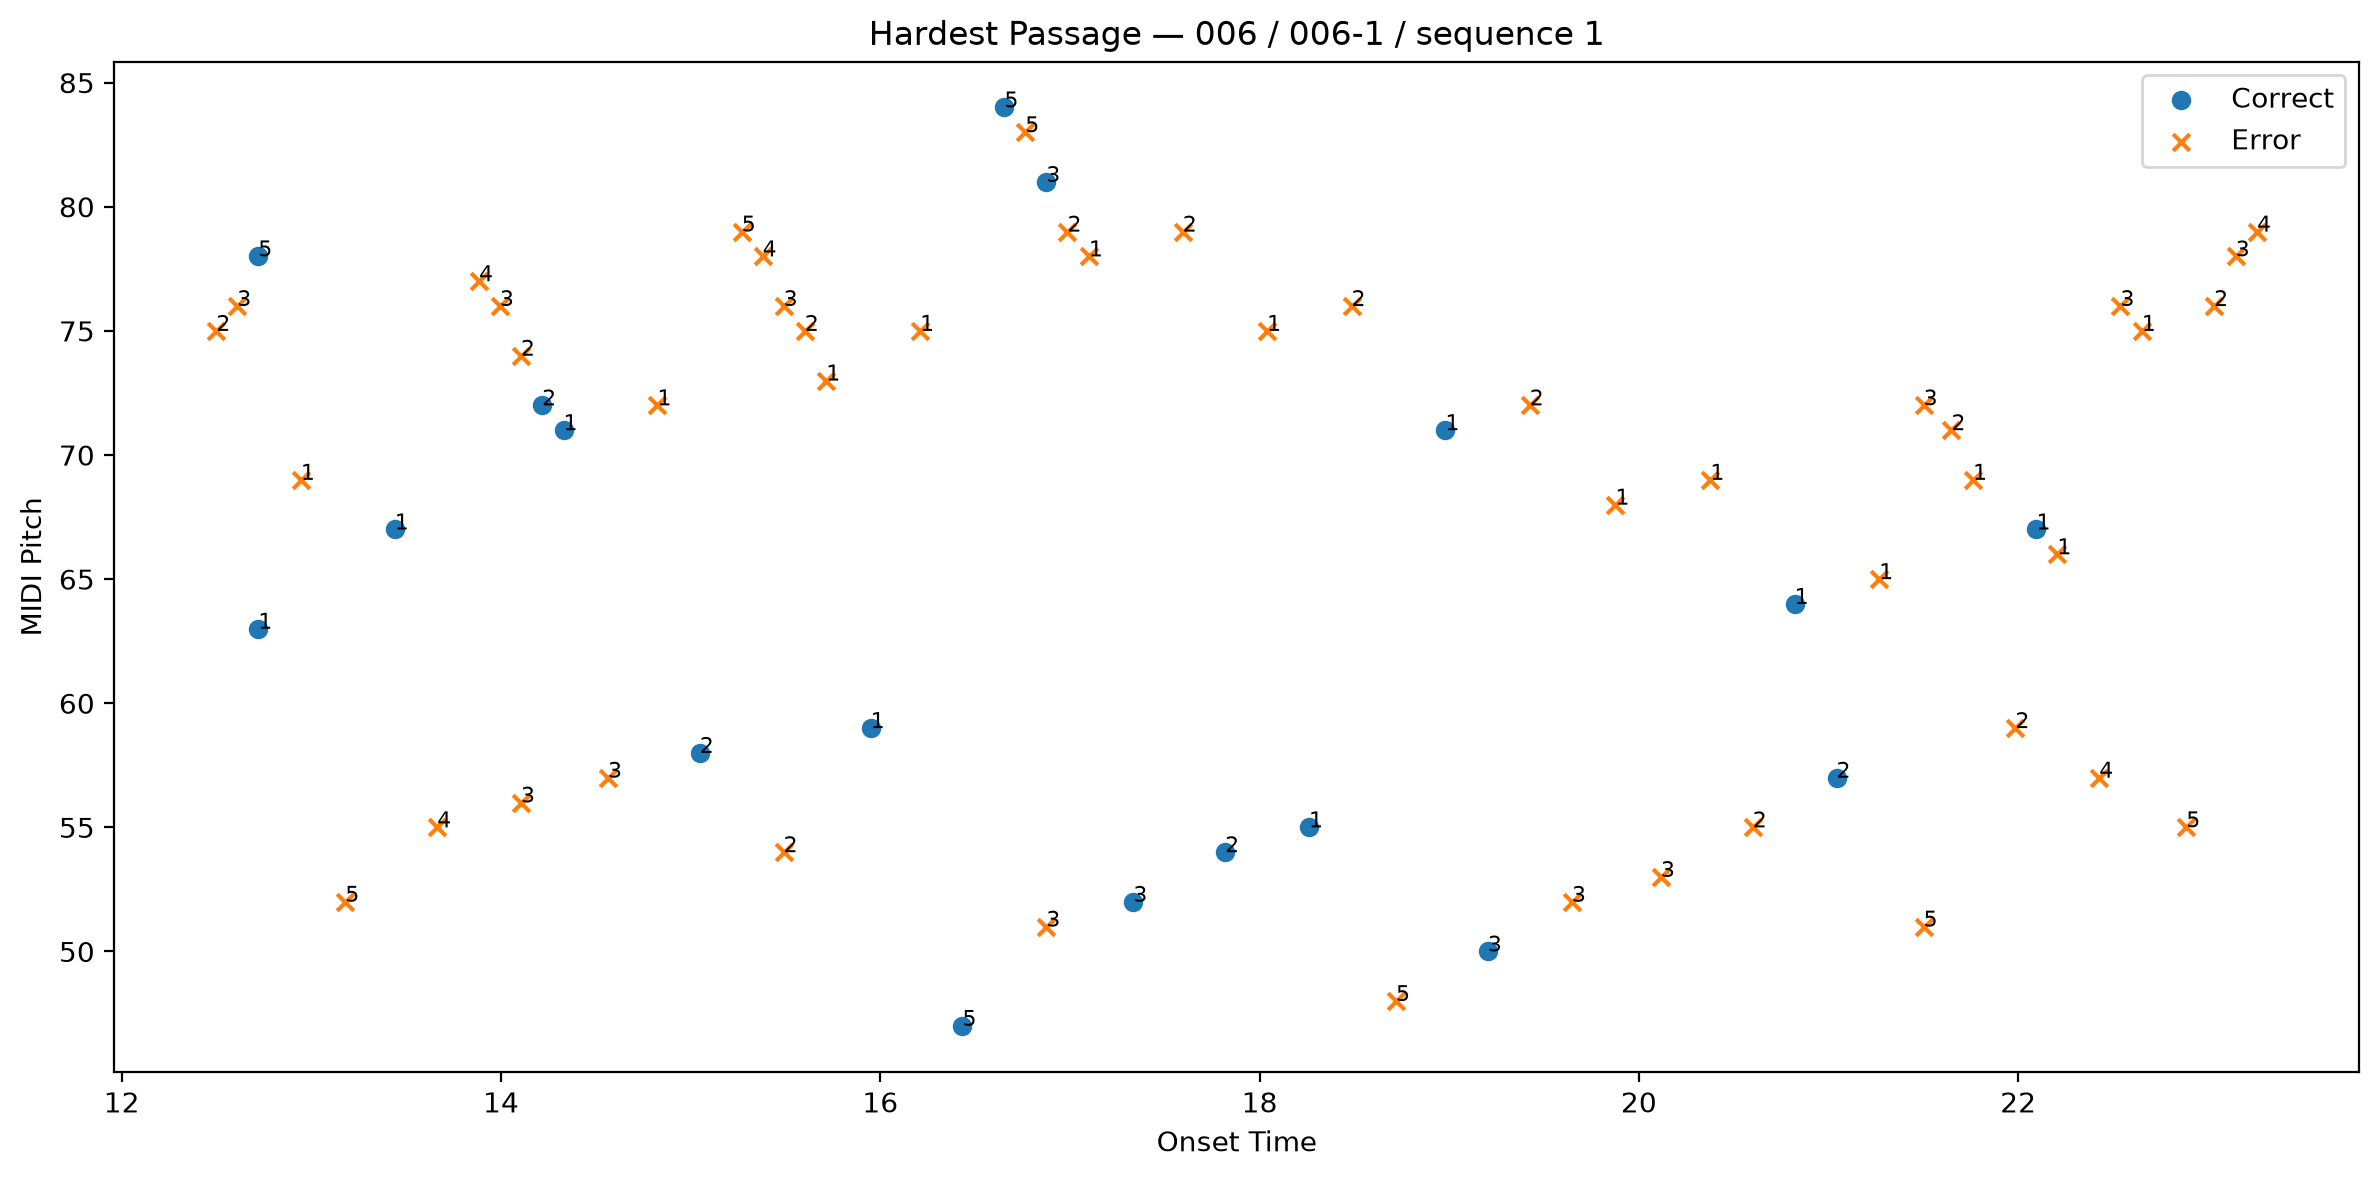

In [28]:
worst = hard_passages.iloc[0]
worst_seq = pred[
    (pred["piece_id"] == worst["piece_id"]) &
    (pred["file_id"] == worst["file_id"]) &
    (pred["sequence_index"] == worst["sequence_index"])
].copy()

plt.figure(figsize=(12, 6))
correct = worst_seq[worst_seq["finger_correct"]]
wrong = worst_seq[~worst_seq["finger_correct"]]

plt.scatter(correct["onset_time"], correct["midi_pitch"], marker="o", label="Correct")
plt.scatter(wrong["onset_time"], wrong["midi_pitch"], marker="x", label="Error")

for _, row in worst_seq.iterrows():
    plt.text(
        row["onset_time"], row["midi_pitch"],
        str(row["pred_finger"]), fontsize=8
    )

plt.xlabel("Onset Time")
plt.ylabel("MIDI Pitch")
plt.title(
    f"Hardest Passage — {worst['piece_id']} / {worst['file_id']} / sequence {int(worst['sequence_index'])}"
)
plt.legend()
plt.tight_layout()
plt.show()

## 15. Week 3 — multiple ground truth agreement

In [29]:
annotation_counts = (
    pred.groupby("piece_id")["file_id"].nunique().sort_values(ascending=False)
)

a_multi = annotation_counts[annotation_counts > 1]
print(f"Birden fazla fingering anotasyonu bulunan test eserleri: {len(a_multi)}")

human_sets = (
    pred.groupby(["piece_id", "note_id"])["true_finger"]
    .agg(lambda s: set(int(v) for v in s))
    .rename("human_finger_set")
    .reset_index()
)

pred_multi = pred.merge(
    human_sets,
    on=["piece_id", "note_id"],
    how="left"
)
pred_multi["multiple_human_refs"] = pred_multi["human_finger_set"].apply(
    lambda s: isinstance(s, set) and len(s) > 1
)
pred_multi["any_human_match"] = pred_multi.apply(
    lambda r: r["pred_finger"] in r["human_finger_set"]
    if isinstance(r["human_finger_set"], set) else False,
    axis=1,
)

coverage = pred_multi["human_finger_set"].notna().mean()
any_match = pred_multi.loc[
    pred_multi["human_finger_set"].notna(), "any_human_match"
].mean()

print(f"Same piece_id + note_id ile birden fazla referansa erişim oranı: {coverage:.4f}")
print(f"Prediction herhangi bir insan referansıyla eşleşme oranı: {any_match:.4f}")

multi_gt_rows = pred_multi[pred_multi["multiple_human_refs"]].copy()
print(f"Birden fazla farklı finger referansı olan note satırları: {len(multi_gt_rows):,}")

Birden fazla fingering anotasyonu bulunan test eserleri: 12
Same piece_id + note_id ile birden fazla referansa erişim oranı: 1.0000
Prediction herhangi bir insan referansıyla eşleşme oranı: 0.7215
Birden fazla farklı finger referansı olan note satırları: 5,782


## 16. Export

In [30]:
prediction_df.to_csv("test_note_level_predictions.csv", index=False)
piece_metrics.to_csv("test_piece_metrics.csv", index=False)
hard_passages.to_csv("hard_passages.csv", index=False)
experiment_results_df.to_csv("hyperparameter_results.csv", index=False)

print("CSV sonuçları kaydedildi.")

CSV sonuçları kaydedildi.
